# Heat Transfer Coefficient (HTC) Interpolation Example

This notebook demonstrates interpolating convection boundary conditions (HTC and reference temperature) from a source mesh to a destination mesh using the DISTANCE_WEIGHTED kernel with k=3 nearest neighbors.

HTC is a 2-component load:
- **Component 1**: Heat Transfer Coefficient (W/m²·K)
- **Component 2**: Reference (bulk fluid) temperature (K)

The ANSYS APDL export uses `SFE,,CONV,1` for HTC and `SFE,,CONV,2` for the reference temperature.

In [6]:
from interpcore.interpolator import Interpolator
from interpcore.config import InterpolationConfig, QUERY_TYPE, INTERPOLATED_LOAD_TYPE
from interpcore.kernels import INTERPOLATION_KERNEL

## Configure and Run Interpolation

In [7]:
# Create configuration for AVERAGE kernel with HTC load type
config = InterpolationConfig(
    method=QUERY_TYPE.K,
    param=3,
    max_distance=2.0,
    coincidence_tolerance=0.01,
    kernel=INTERPOLATION_KERNEL.AVERAGE,
    multithread=False,
    interpolated_load=INTERPOLATED_LOAD_TYPE.HTC
)

# Define file column indices
# The source file has columns: Node_ID X Y Z HTC Tref
# val=4 means values start at column index 4 (HTC), and num_components=2 reads HTC + Tref
file_idx = {"ids": 0, "dest_x": 1, "src_x": 1, "val": 4}

# Create interpolator
interpolator = Interpolator(
    path_to_src_folder="source_data",
    path_to_dest_mesh="destination_mesh.txt",
    config=config,
    file_idx=file_idx
)

# Run interpolation
interpolator.interpolate_all()
print("Interpolation completed!")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 48.60it/s]

Interpolation completed!


## Export to APDL format

In [8]:
from tempfile import TemporaryDirectory

with TemporaryDirectory() as tmp_dir:
    interpolator.export_to_ansys(tmp_dir)

    # Preview the exported file content
    with open(f"{tmp_dir}/interpolated_htc_data.txt", "r") as f:
        for line in f.readlines()[:10]:
            print(line.strip())

SFE, 101.0,, CONV, 1, 154.33333333333334
SFE, 102.0,, CONV, 1, 154.33333333333334
SFE, 103.0,, CONV, 1, 155.66666666666666
SFE, 104.0,, CONV, 1, 162.33333333333334
SFE, 105.0,, CONV, 1, 167.0
SFE, 106.0,, CONV, 1, 170.0
SFE, 107.0,, CONV, 1, 177.66666666666666
SFE, 108.0,, CONV, 1, 182.33333333333334
SFE, 109.0,, CONV, 1, 184.33333333333334
SFE, 110.0,, CONV, 1, 190.33333333333334


## View Results

It is possible to explore the interpolated results by producing VTK files. These can be either visualized directly using pyvista or exported to `.vtk` to be further processed later in ParaView.

For a 2-component load like HTC, the VTK output stores both components: `Component_0` (HTC) and `Component_1` (Tref).

In [9]:
import pyvista as pv
import matplotlib.pyplot as plt

interpolator.build_vtk_output(outdir=None)  # set to an existing path to export vtk files

This is boilerplate code to plot both components (HTC and Tref) side by side directly in the notebook.

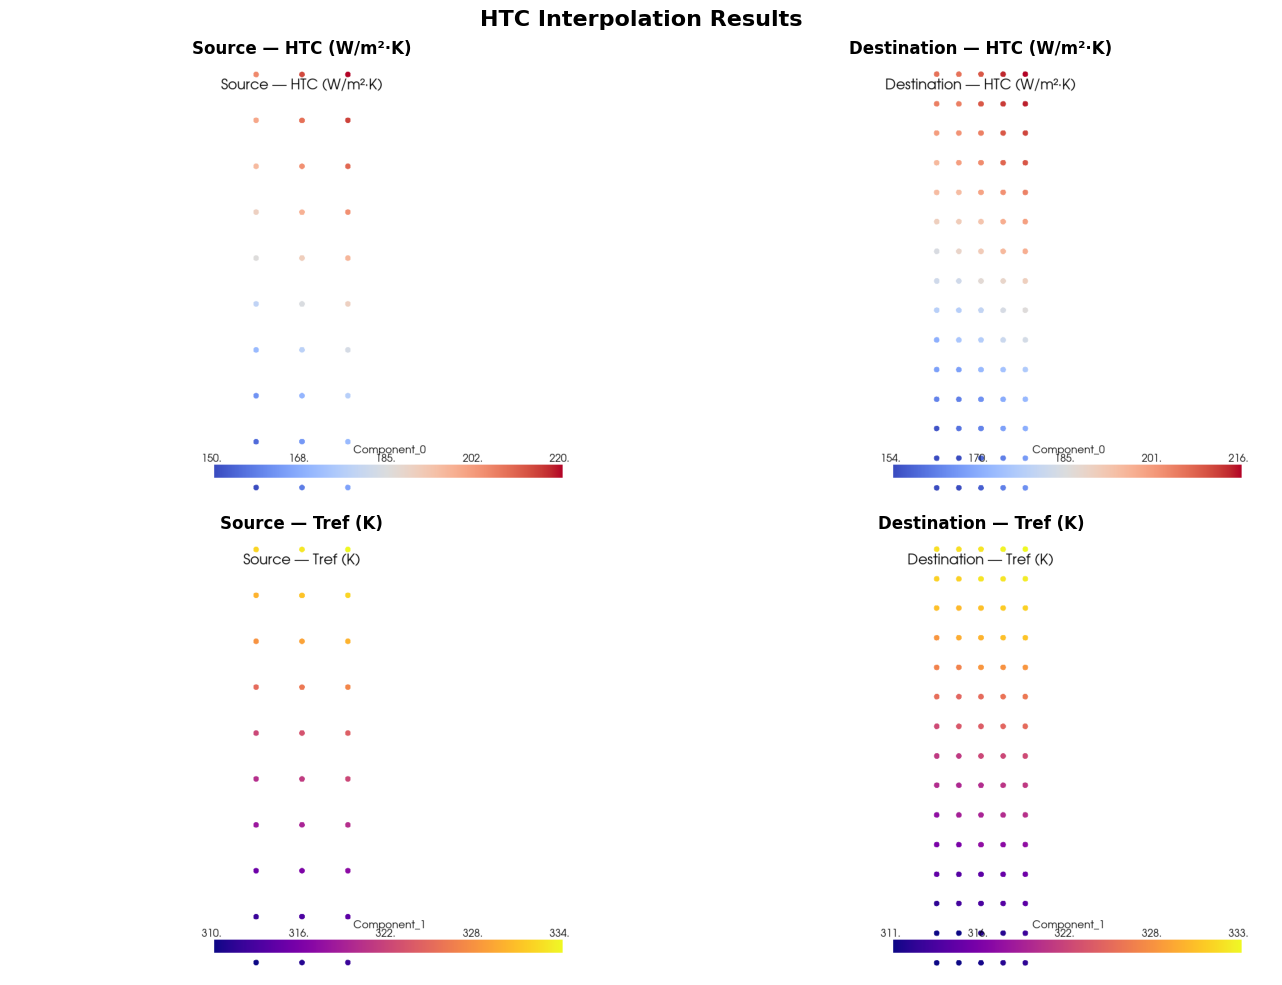

In [10]:
source_cloud = interpolator.src_vtk["htc_data"]
dest_cloud = interpolator.dest_vtk["htc_data"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HTC Interpolation Results', fontsize=16, fontweight='bold')

components = [
    ("Component_0", "HTC (W/m²·K)", "coolwarm"),
    ("Component_1", "Tref (K)", "plasma"),
]

for row, (scalar, title, cmap) in enumerate(components):
    # Source cloud
    plotter_src = pv.Plotter(off_screen=True)
    plotter_src.add_mesh(source_cloud, scalars=scalar, cmap=cmap, point_size=10,
                         render_points_as_spheres=False, style='points')
    plotter_src.add_title(f'Source — {title}', font_size=11)
    plotter_src.camera_position = 'xy'
    img_src = plotter_src.screenshot(return_img=True)
    plotter_src.close()

    # Destination cloud
    plotter_dest = pv.Plotter(off_screen=True)
    plotter_dest.add_mesh(dest_cloud, scalars=scalar, cmap=cmap, point_size=10,
                          render_points_as_spheres=False, style='points')
    plotter_dest.add_title(f'Destination — {title}', font_size=11)
    plotter_dest.camera_position = 'xy'
    img_dest = plotter_dest.screenshot(return_img=True)
    plotter_dest.close()

    axes[row, 0].imshow(img_src)
    axes[row, 0].axis('off')
    axes[row, 0].set_title(f'Source — {title}', fontsize=12, fontweight='bold')

    axes[row, 1].imshow(img_dest)
    axes[row, 1].axis('off')
    axes[row, 1].set_title(f'Destination — {title}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()